### We are going to analyze Waze a navigation app data set to find which factors are highest factor for User Churn.

### KPI/KPQ:

1) What percentage of users churned?
2) Are new users more likely to churn than experienced users?
3) Do churned users take fewer trips than retained users?
4) How does the number of drives affect churn probability?
5) Does device type (Android/iPhone) influence churn?
6) Is there a relationship between navigation sessions and churn?
7) Which factors contribute most to churn?
8) What percentage of churn could potentially be prevented?

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
import datetime as dt

In [51]:
try:
    df = pd.read_csv("data/waze_dataset.csv")
    print("data read Successfully")
except FileNotFoundError as e:
    print(f'read dataset faile error is {e}')

data read Successfully


In [52]:
df.head()

,ID,label,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,device
0,0,retained,283,226,296.748273,2276,208,0,2628.845068,1985.775061,28,19,Android
1,1,retained,133,107,326.896596,1225,19,64,13715.920550,3160.472914,13,11,iPhone
2,2,retained,114,95,135.522926,2651,0,0,3059.148818,1610.735904,14,8,Android
3,3,retained,49,40,67.589221,15,322,7,913.591123,587.196542,7,3,iPhone
4,4,retained,84,68,168.247020,1562,166,5,3950.202008,1219.555924,27,18,Android


In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       14999 non-null  int64  
 1   label                    14299 non-null  object 
 2   sessions                 14999 non-null  int64  
 3   drives                   14999 non-null  int64  
 4   total_sessions           14999 non-null  float64
 5   n_days_after_onboarding  14999 non-null  int64  
 6   total_navigations_fav1   14999 non-null  int64  
 7   total_navigations_fav2   14999 non-null  int64  
 8   driven_km_drives         14999 non-null  float64
 9   duration_minutes_drives  14999 non-null  float64
 10  activity_days            14999 non-null  int64  
 11  driving_days             14999 non-null  int64  
 12  device                   14999 non-null  object 
dtypes: float64(3), int64(8), object(2)
memory usage: 1.5+ MB


In [54]:
df.describe()

,ID,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,7499.000000,80.633776,67.281152,189.964447,1749.837789,121.605974,29.672512,4039.340921,1860.976012,15.537102,12.179879
std,4329.982679,80.699065,65.913872,136.405128,1008.513876,148.121544,45.394651,2502.149334,1446.702288,9.004655,7.824036
min,0.000000,0.000000,0.000000,0.220211,4.000000,0.000000,0.000000,60.441250,18.282082,0.000000,0.000000
25%,3749.500000,23.000000,20.000000,90.661156,878.000000,9.000000,0.000000,2212.600607,835.996260,8.000000,5.000000
50%,7499.000000,56.000000,48.000000,159.568115,1741.000000,71.000000,9.000000,3493.858085,1478.249859,16.000000,12.000000
75%,11248.500000,112.000000,93.000000,254.192341,2623.500000,178.000000,43.000000,5289.861262,2464.362632,23.000000,19.000000
max,14998.000000,743.000000,596.000000,1216.154633,3500.000000,1236.000000,415.000000,21183.401890,15851.727160,31.000000,30.000000


After carefully looking into data we can see there are 14999 rows and 13 columns, column label have 700 less entries and in descriptive stats we after see little variation in dataset values so there might be outliers in dataset

### 1) What percentage of users churned?

In [55]:
df.dropna(inplace=True)

In [56]:
df['label'].value_counts(normalize=True)*100

label
retained    82.264494
churned     17.735506
Name: proportion, dtype: float64

from data we can see there are almost 18% user were churned in last month(as we have data for last month). Churned user percentage is concerning so we are going look deep into it

### 2) Are new users more likely to churn than experienced users?

Currently we dont have any column who can say whether user is new or experienced but we will add one more column in data.if user have passed more than 30 day since he joined
the app 


In [57]:
df['user_category'] = np.where(df['n_days_after_onboarding']<=30,"new_driver",'experienced_driver')

In [58]:
df['user_category'].value_counts()

user_category
experienced_driver    14181
new_driver              118
Name: count, dtype: int64

In [59]:
res = pd.crosstab(df['label'],df['user_category'])
res

user_category,experienced_driver,new_driver
label,,
churned,2507,29
retained,11674,89


In [60]:
churned_user_data=df[df['label']=='churned']

In [61]:
total_exp_user_churn = len(churned_user_data[churned_user_data['user_category']=='experienced_driver'])*100/len(df['user_category'])
total_exp_user_churn

17.532694594027554

In [62]:
total_new_user_churn = len(churned_user_data[churned_user_data['user_category']=='new_driver'])*100/len(df['user_category'])
total_new_user_churn

0.20281138541156724

In [63]:
len(churned_user_data[churned_user_data['user_category']=='experienced_driver'])*100/len(churned_user_data['user_category'])

98.85646687697161

In [64]:
len(churned_user_data[churned_user_data['user_category']=='new_driver'])*100/len(churned_user_data['user_category'])

1.1435331230283912

We can see from whole dataset 17.53% of people who are churned are Experienced one but less than 1 new_users are churned. This might be because there are very less new drivers like around 118. Even if consider only Churn user dataset 98.85% of experienced drivers and 1.14% of new user were churns

### 3) Do churned users take fewer trips than retained users?
### 4) How does the distances drive by user affect churn probability?
### 6) Is there a relationship between navigation sessions and churn?

In [65]:
df.groupby(['label']).median(numeric_only=True)

,ID,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days
label,,,,,,,,,,,
churned,7477.5,59.0,50.0,164.339042,1321.0,84.5,11.0,3652.655666,1607.183785,8.0,6.0
retained,7509.0,56.0,47.0,157.586756,1843.0,68.0,9.0,3464.684614,1458.046141,17.0,14.0


from above result we can say churned user have take only 3 drives more than retained user which not likely controbuting toward user churn. 
Similarly churned user only drive ~200 km and 2.5 hours more than reatined user we are not getting strong evidence for user churn.
There is very less difference in total sessions of navigation between Churned and retained user its ~7 session more than retained user.

### 5) Does device type (Android/iPhone) influence churn?

In [74]:
df['device'].value_counts()

device
iPhone     9225
Android    5074
Name: count, dtype: int64

In [66]:
df.groupby(['label', 'device']).size()

label     device 
churned   Android     891
          iPhone     1645
retained  Android    4183
          iPhone     7580
dtype: int64

people who are using iPhone have almost double number than android users. 1645 user are who uses iPhone are churned whereas only 891 android user. this might one most important factor for user churn might be iPhone users facing some issue with navigation app organization must have to look into it

### 7) Which factors contribute most to churn?

Until now we found out that device type have significant effect on user Churn. We will try to do extract some features, might be they are having impact on user churn

Lets see how much user drive per day as well as how many drives per day user have. Alongside of that we can check for how much km user have drove per drive

In [67]:
df['km_per_driving_day'] = df['driven_km_drives']/df['driving_days']
df.groupby('label').median(numeric_only=True)[['km_per_driving_day']]

,km_per_driving_day
label,
churned,697.541999
retained,289.549333


In [68]:
df['drives_per_day']=df['drives']/df['driving_days']
df.groupby('label').median(numeric_only=True)[['drives_per_day']]

,drives_per_day
label,
churned,10.0000
retained,4.0625


In [69]:
df['km_per_drive']=df['driven_km_drives']/df['drives']
df.groupby('label').median(numeric_only=True)[['km_per_drive']]

,km_per_drive
label,
churned,74.109416
retained,75.014702


Here we can see that user who churn have drove ~500 km more per day than user who have retained similarly to drives per day churn user have 6 more drives per day than retained.From above results we can say people who drove more distance per day and have more drives per day have tendency to churn. There is not much effect of how much user drove per drive to the churn

### 8) What percentage of churn could potentially be prevented?

Basically after all results we can see that there are some factors that are effectively affecting churn. we will try to find which factor have more effect for churn

we will isolate those features and we will try to plot bar graph to see which feature is effect. we have one feature i.e device which is string categorical varible we will convert that to the continous varible with 1 and 0

In [116]:
X = df.copy()

In [117]:
X = X[['device','km_per_driving_day','drives_per_day','label']]


In [118]:
X['km_per_driving_day'] = pd.qcut(X['km_per_driving_day'],3,labels=['High','Medium','Low'])
X.head()

c:\Users\maneo\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\function_base.py:4655: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


,device,km_per_driving_day,drives_per_day,label
0,Android,High,11.894737,retained
1,iPhone,Low,9.727273,retained
2,Android,Medium,11.875000,retained
3,iPhone,Medium,13.333333,retained
4,Android,Medium,3.777778,retained


In [119]:
X['drives_per_day']=pd.qcut(X['drives_per_day'],3,labels=['High','Medium','Low'])
X.head()

c:\Users\maneo\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\function_base.py:4655: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


,device,km_per_driving_day,drives_per_day,label
0,Android,High,Low,retained
1,iPhone,Low,Low,retained
2,Android,Medium,Low,retained
3,iPhone,Medium,Low,retained
4,Android,Medium,Medium,retained


In [123]:
churned_drives = pd.crosstab(X['drives_per_day'],X['label'],normalize='index')*100
churned_drives

label,churned,retained
drives_per_day,,
High,10.081744,89.918256
Medium,14.222966,85.777034
Low,28.966245,71.033755


In [124]:
churned_km_day = pd.crosstab(X['km_per_driving_day'],X['label'],normalize='index')*100
churned_km_day

label,churned,retained
km_per_driving_day,,
High,8.558842,91.441158
Medium,14.057910,85.942090
Low,30.591691,69.408309


In [125]:
churned_device = pd.crosstab(X['device'],X['label'],normalize='index')*100
churned_device

label,churned,retained
device,,
Android,17.560110,82.439890
iPhone,17.831978,82.168022


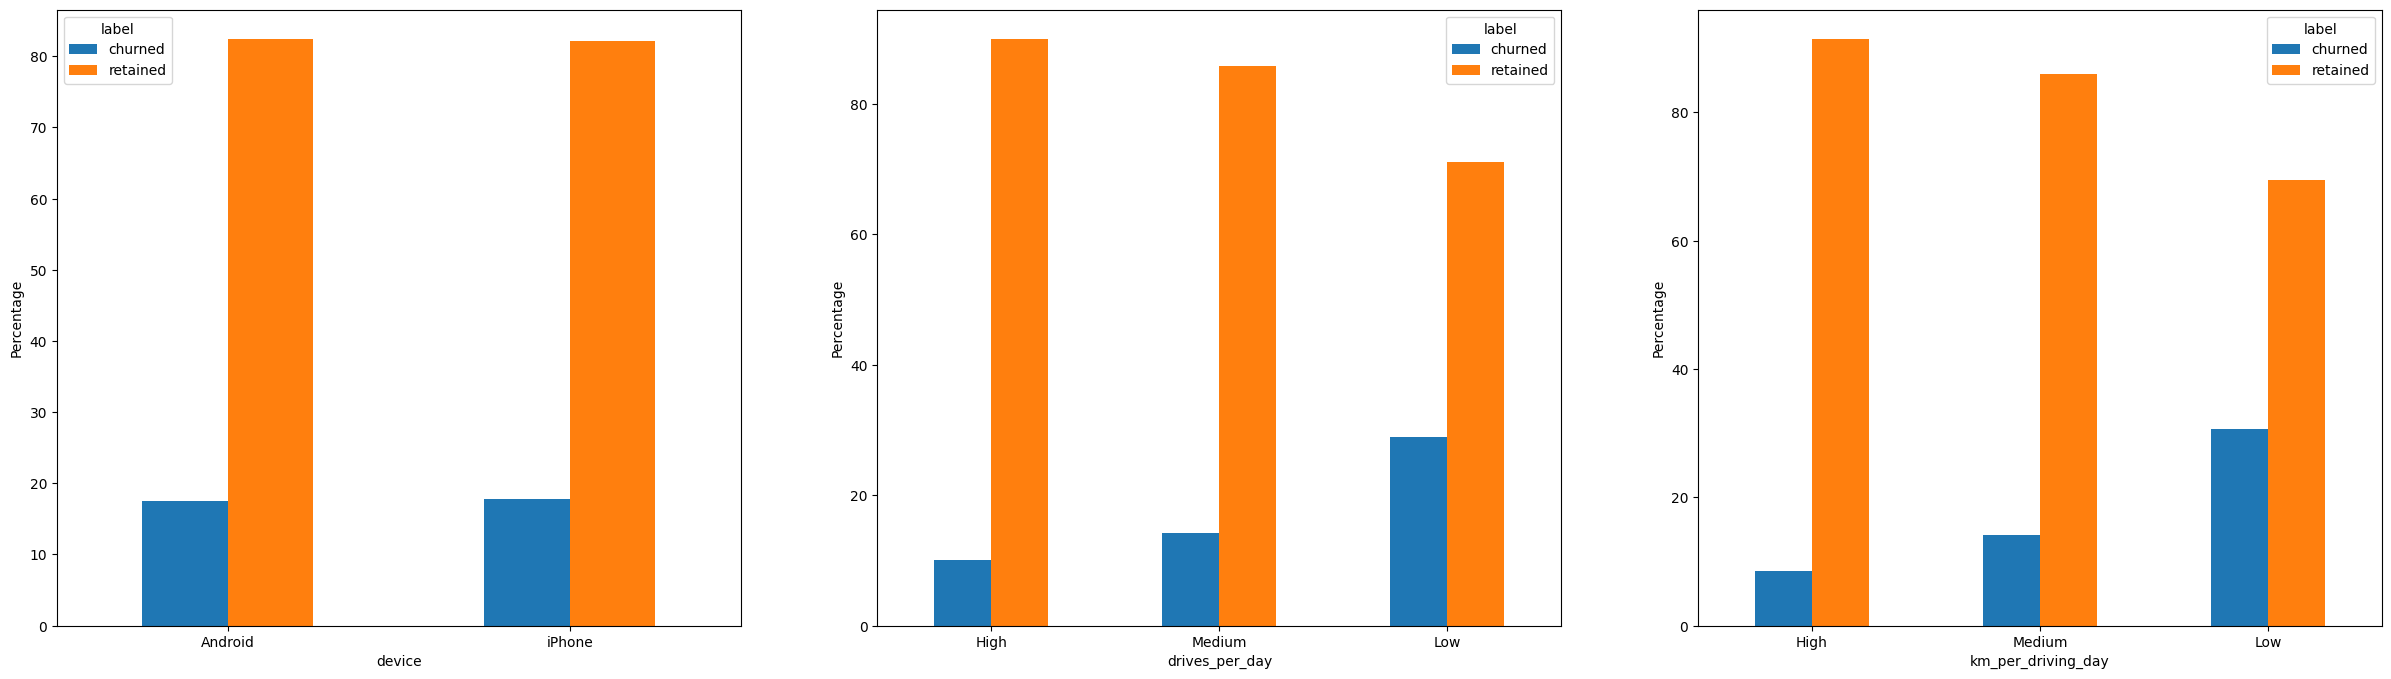

In [142]:
fig, ax = plt.subplots(1,3,figsize=(30,8))
churned_device.plot(kind='bar',ax=ax[0])
ax[0].tick_params(axis='x',labelrotation=0)
ax[0].set_ylabel('Percentage')
churned_drives.plot(kind='bar',ax=ax[1])
ax[1].set_ylabel('Percentage')
ax[1].tick_params(axis='x',labelrotation=0)
churned_km_day.plot(kind='bar',ax=ax[2])
ax[2].set_ylabel('Percentage')
ax[2].tick_params(axis='x',labelrotation=0)

### Conclusion

1) From chart we can say that user with low drives per day and low km drove per day have contribute more in churn its around ~29% and ~30% percentage respectively. 
2) We can put some promotions for this users so that they willingly have more drides. 
3) At start we assume that device might have contribution toward churn but in bar graph we can see both device type have almost similar percentage of churn.
4) Generally, users who churned drove farther and longer in fewer days than retained users. 